In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def count_unargmaxable(W):

    num_of_argmaxable_rows = 0

    # Iterate over each row of W
    for idx, wc in enumerate(W):

        # Compute matrix vector product
        x = W @ wc

        # Obtain result of dot product of w_c with itself
        wc_dot = x[idx]

        # Remove dot product of w_c with itself from x
        others = np.delete(x, idx)

        # If wc_dot is strictly greater than all other dot products of wc with the other rows
        if np.all(wc_dot > others):
            num_of_argmaxable_rows += 1

    # Return True if the condition is true for all rows of W
    return num_of_argmaxable_rows

In [3]:
W = np.random.standard_normal((5, 5))

n_argmaxable = count_unargmaxable(W)
print(f"Percatange of argmaxable rows: {100 * n_argmaxable / W.shape[0]} %")

Percatange of argmaxable rows: 60.0 %


In [7]:
def find_argmaxable_for_ratio(n_rows, d_min, d_max, d_step=1, num_of_tests=3, print_results=False, normalise_rows=False):
    
    # Initialise arrays containing number of features and ratios of number of rows by number of features
    num_features = np.arange(d_min, d_max + 1, step=d_step, dtype=int)
    ratio = n_rows / num_features

    # Initialise array to store results
    perc_of_argmax = np.zeros(len(ratio))

    
    for idx, d in enumerate(num_features):

        # Initialising variable to store number of argmaxable classes in W
        n_argmaxable = 0

        # Compute number of argmaxable classes "num_tests" times - done to reduce variability
        for iter in range(num_of_tests):
            W = np.random.standard_normal((n_rows, d))

            if (normalise_rows):
                # Source: https://stackoverflow.com/questions/36267936/normalizing-rows-of-a-matrix-python
                norms_of_rows = np.linalg.norm(W, axis=1, ord=2)
                W = (W.T / norms_of_rows).T

            n_argmaxable += count_unargmaxable(W)

        # Compue mean of results, and use mean to compute percentage of argmaxable rows
        n_argmaxable *= (1 / num_of_tests)
        perc_of_argmax[idx] =  100 * n_argmaxable / n_rows

        if (print_results):
            print(f"Ratio n/d: {n_rows / d:.02f} | Percatange of argmaxable rows: {100 * n_argmaxable / W.shape[0]:.02f}%")
    
    return perc_of_argmax, ratio

In [30]:
def plot_argmaxable_to_ratio(perc_of_argmax, ratio, title="Percentage of Rows of W which are argmaxable", ax=None):

    if (ax is None):
        # print("Entered")
        plt.figure(figsize=(10, 6))
        ax = plt.gca()
    
    ax.plot(ratio, perc_of_argmax, 'o-')
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Ratio: number of rows / number of features", fontsize=14)
    ax.set_ylabel("Percentage [%]", fontsize=14)
    ax.grid()
    ax.axvline(x=1, color='red', linestyle='--', label=r"Ratio $\frac{n}{d} = 1$")
    ax.legend(fontsize=14)
    ax.set_ylim([0, 105])

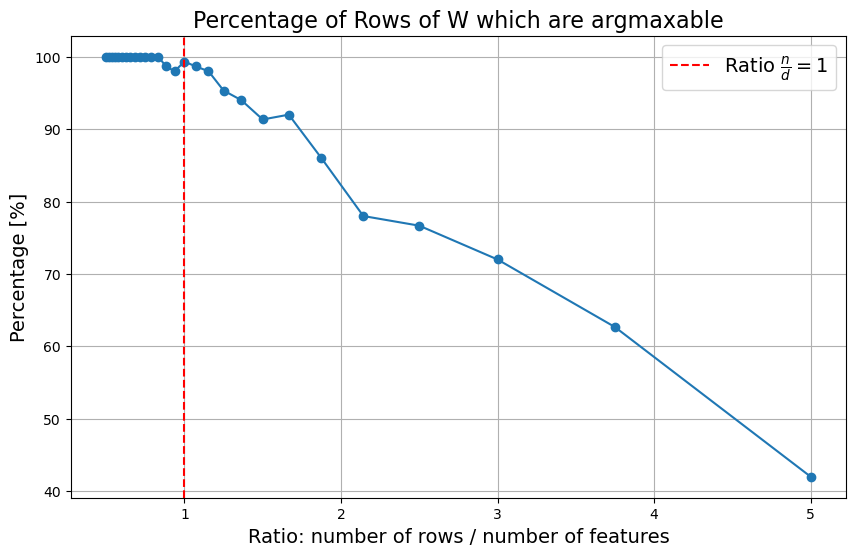

In [138]:
perc_of_argmax, ratio = find_argmaxable_for_ratio(n_rows=15, d_min=3, d_max=30, d_step=1, num_of_tests=10, print_results=False)
plot_argmaxable_to_ratio(perc_of_argmax=perc_of_argmax, ratio=ratio)

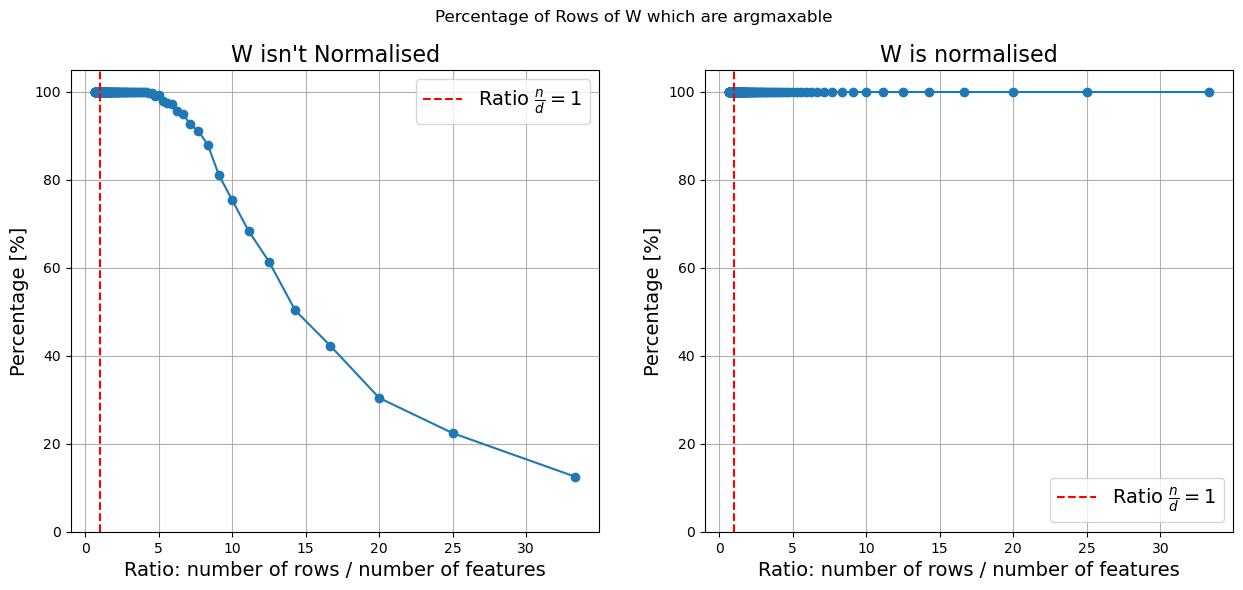

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
fig.suptitle("Percentage of Rows of W which are argmaxable", fontsize=16)


# Performing Tests when Unembedding Matrix W isn't normalised and when it is
perc_of_argmax, ratio = find_argmaxable_for_ratio(n_rows=100, d_min=3, d_max=150, d_step=1, num_of_tests=10, print_results=False, normalise_rows=False)
perc_of_argmax_normalised, ratio_normalised = find_argmaxable_for_ratio(n_rows=100, d_min=3, d_max=150, d_step=1, num_of_tests=10, print_results=False, normalise_rows=True)

plot_argmaxable_to_ratio(perc_of_argmax=perc_of_argmax, ratio=ratio, ax=axs[0], title="W isn't Normalised")
plot_argmaxable_to_ratio(perc_of_argmax=perc_of_argmax_normalised, ratio=ratio_normalised, ax=axs[1], title="W is normalised")

plt.show()